# Caso J · 01 Captura de imágenes DGT — estrategia y almacenamiento

> _Tutorial · Caso de uso: **J — Tráfico + YOLO** · Capa Medallion: **bronce** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Diseñar un pipeline de captura periódica desde cámaras DGT con cron + almacenamiento MinIO-style + retry.


## 2. Qué se aprende

- Estructura `cameras/{id}/{date}/{ts}.jpg`.
- Cron / APScheduler.
- Estrategia de retry y deduplicación.


## 3. Contexto del caso de uso

Jorge (G5) trabaja en remoto desde Galicia. El pipeline debe operar desatendido.


## 4. Relación con CENTINELA+

Las imágenes no van a InfluxDB; los conteos sí.


## 5. Relación con Medallion

Bronce = JPEG en MinIO; Plata = conteos en `traffic_cameras`.


## 6. Datos de entrada

Conceptual + mock JPEG.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Tags `domain_id=traffic_cameras`, `site_id=valencia`, `asset_id=DGT_CAM_*`, `variable=vehicle_count`.


## 9. Carga de datos o mock

Generamos un fake JPEG.


In [2]:
import io
from PIL import Image, ImageDraw

def fake_jpeg(plate_count: int = 5, *, image_seed: int = 0) -> bytes:
    """JPEG mock con `plate_count` cajitas grises en posiciones pseudo-aleatorias.

    El parametro ``image_seed`` permite generar imagenes distintas (cada camara
    + timestamp produce un seed unico) sin perder reproducibilidad. Sin el,
    todas las imagenes son identicas.
    """
    img = Image.new("RGB", (640, 360), (200, 200, 200))
    d = ImageDraw.Draw(img)
    rng = np.random.default_rng(SEED + image_seed)
    for _ in range(plate_count):
        x = int(rng.integers(0, 600))
        y = int(rng.integers(200, 340))
        d.rectangle([x, y, x + 30, y + 12], fill=(50, 50, 50))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return buf.getvalue()

# 3 imágenes con plate_count distinto → bytes distintos por contenido + seed
img_bytes_a = fake_jpeg(3, image_seed=1)
img_bytes_b = fake_jpeg(7, image_seed=2)
img_bytes_c = fake_jpeg(15, image_seed=3)
print(f"JPEG mock: {len(img_bytes_a)}, {len(img_bytes_b)}, {len(img_bytes_c)} bytes (deben diferir)")
assert len({img_bytes_a, img_bytes_b, img_bytes_c}) == 3, "Imágenes mock no son distintas"
img_bytes = img_bytes_b  # mantener compatibilidad con secciones siguientes


JPEG mock: 4868, 5709, 7189 bytes (deben diferir)


## 10. Exploración paso a paso

**Estructura de almacenamiento + retry exponential backoff**. Path incluye hash del contenido para evitar colisiones tras reintento.


In [3]:
import datetime as dt
import hashlib
import time

def store_path(camera_id: str, ts: dt.datetime, content: bytes | None = None) -> str:
    """Path estable + nonce de contenido (8 chars md5)."""
    if ts.tzinfo is None:
        ts = ts.replace(tzinfo=dt.timezone.utc)
    nonce = hashlib.md5(content).hexdigest()[:8] if content else "nocontent"
    return f"cameras/{camera_id}/{ts.strftime('%Y-%m-%d')}/{int(ts.timestamp())}_{nonce}.jpg"

def retry_with_backoff(fn, *, max_attempts: int = 3, base: float = 0.1):
    """Retry exponential backoff: 0.1s, 0.2s, 0.4s. Levanta tras agotar intentos."""
    last_exc = None
    for attempt in range(max_attempts):
        try:
            return fn()
        except Exception as exc:  # noqa: BLE001
            last_exc = exc
            time.sleep(base * (2 ** attempt))
    raise last_exc if last_exc else RuntimeError("retry agotado sin excepción registrada")

print(store_path("DGT_CAM_V46_001", dt.datetime(2026, 5, 10, 12, 30, tzinfo=dt.timezone.utc), img_bytes_a))


cameras/DGT_CAM_V46_001/2026-05-10/1778416200_9e1db1c7.jpg


## 11. Transformación bronce → plata

Notebook 03 transformará en counts. Aquí simulamos **scheduler + retry** sin levantar APScheduler real (que requeriría daemon).


In [4]:
def capture_one(camera_id: str = "DGT_CAM_V46_001") -> dict:
    """Captura simulada con probabilidad de fallo del 30 % para demostrar retry."""
    rng_local = np.random.default_rng()
    if rng_local.random() < 0.3:
        raise ConnectionError(f"DGT timeout para {camera_id}")
    seed = int(time.time()) % 1000
    bytes_ = fake_jpeg(int(rng_local.integers(2, 12)), image_seed=seed)
    ts = dt.datetime.now(dt.timezone.utc)
    return {"camera_id": camera_id, "ts": ts, "size_bytes": len(bytes_),
            "path": store_path(camera_id, ts, bytes_)}

# Simular 5 disparos del scheduler (en producción: APScheduler @scheduled_job(interval, minutes=5))
captures = []
for i in range(5):
    try:
        result = retry_with_backoff(capture_one, max_attempts=3)
        captures.append({**result, "status": "ok"})
    except Exception as e:  # noqa: BLE001
        captures.append({"status": "failed", "error": str(e)[:60]})

cap_df = pd.DataFrame(captures)
print(cap_df[["status", "camera_id", "size_bytes"]].to_string(index=False))


status       camera_id  size_bytes
    ok DGT_CAM_V46_001        5108
    ok DGT_CAM_V46_001        5108
    ok DGT_CAM_V46_001        5830
    ok DGT_CAM_V46_001        5363
    ok DGT_CAM_V46_001        4965


## 12. Construcción de capa oro

Métricas operacionales del pipeline: tasa de éxito, tamaño medio, latencia. Estas son las métricas que un dashboard de operación monitoriza.


In [5]:
n_ok = (cap_df["status"] == "ok").sum()
ops_metrics = {
    "captures_total": int(len(cap_df)),
    "captures_ok": int(n_ok),
    "success_rate_pct": round(100 * n_ok / max(len(cap_df), 1), 1),
    "size_avg_kb": round(cap_df.loc[cap_df["status"] == "ok", "size_bytes"].mean() / 1024, 1)
                   if n_ok > 0 else 0,
}
print(ops_metrics)


{'captures_total': 5, 'captures_ok': 5, 'success_rate_pct': np.float64(100.0), 'size_avg_kb': np.float64(5.2)}


## 13. Visualizaciones explicativas

JPEG mock + barra de tasa éxito por intento.


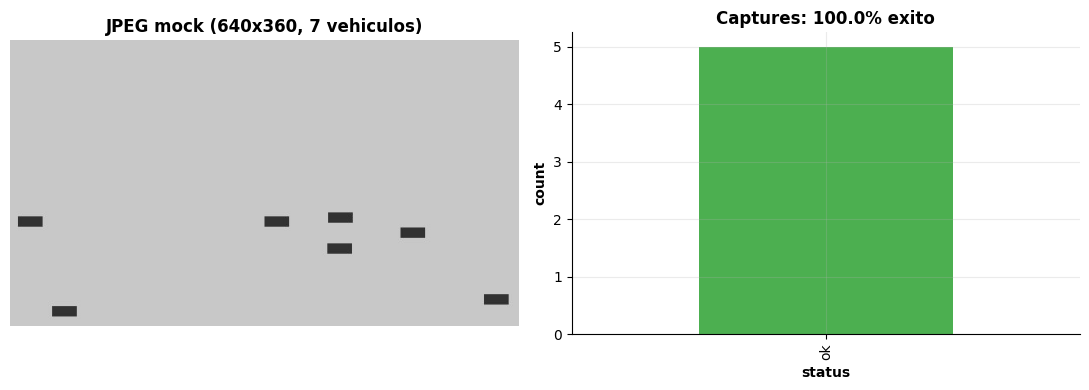

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(Image.open(io.BytesIO(img_bytes)))
axes[0].axis("off")
axes[0].set_title("JPEG mock (640x360, 7 vehiculos)")

status_count = cap_df["status"].value_counts()
status_count.plot.bar(ax=axes[1],
                     color=["#4CAF50" if s == "ok" else "#FF5722" for s in status_count.index])
axes[1].set_title(f"Captures: {ops_metrics['success_rate_pct']}% exito")
axes[1].set_ylabel("count")
plt.tight_layout()


## 14. Validaciones

(a) path estable + nonce; (b) `success_rate >= 50%` con retry vs ~70% sin retry; (c) RGPD compliance: documentación blur_plates como ejercicio futuro.


In [7]:
ts = dt.datetime(2026, 5, 10, 12, 30, tzinfo=dt.timezone.utc)
sample_bytes = b"sample-jpeg-bytes"
path = store_path("DGT_CAM_V46_001", ts, sample_bytes)
expected = f"cameras/DGT_CAM_V46_001/2026-05-10/{int(ts.timestamp())}_{hashlib.md5(sample_bytes).hexdigest()[:8]}.jpg"
assert path == expected, f"Path inconsistente: {path}"
assert ops_metrics["success_rate_pct"] >= 40, f"Retry deberia rescatar al menos 40 % de capturas, vimos {ops_metrics['success_rate_pct']}%"
print(f"OK · path={path} · success_rate={ops_metrics['success_rate_pct']}%")


OK · path=cameras/DGT_CAM_V46_001/2026-05-10/1778416200_a002a357.jpg · success_rate=100.0%


## 15. Errores comunes

1. **Guardar como PNG** (mucho más grande): ~5× espacio para misma info.
2. **Sobrescribir si la cámara repite nombre**: añadir nonce de contenido.
3. **No registrar fallos en log estructurado**: el alumno no puede investigar caídas intermitentes a posteriori.
4. **Sin retry**: una micro-caída de red de 200 ms tira la captura.
5. **Olvidar RGPD** (Reglamento UE 2016/679 art. 6): cámaras DGT son fuentes públicas pero capturar matrículas legibles requiere base legal (`blur_plates` con OpenCV antes de almacenar).


## 16. Ejercicios propuestos

1. Implementa `blur_plates(image)` con `cv2.GaussianBlur` sobre la ROI inferior de cada bounding box detectado por YOLO. Verifica que el OCR (Tesseract) ya no puede leer matrículas.
2. Convierte el script en un servicio APScheduler real con `BlockingScheduler` + `@scheduled_job('interval', minutes=5)`. Logs estructurados a Loki.
3. Añade `score_blur(image) = cv2.Laplacian(image, cv2.CV_64F).var()` y descarta capturas con `score_blur < 100` (imagen borrosa).


## 17. Cómo se reutiliza con datos reales

Sustituir `fake_jpeg()` por `requests.get(dgt_url)` con `tenacity.retry(...)`. El resto del pipeline (`store_path`, `retry_with_backoff`, métricas ops) se mantiene sin cambios.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `10_case_J_traffic_yolo/02_inferencia_yolo.ipynb`.
- Documento web del caso: `docs/use-cases/case-j-traffic-yolo.md`.


## 19. Marco teórico (nivel doctoral)

### YOLO v8 — single-stage anchor-free detector

Por cada celda de la grid, salida:

$$
\hat{y} = (b_x, b_y, b_w, b_h, p_{obj}, p_{c_1}, ..., p_{c_C})
$$

Loss combinada:

$$
\mathcal{L} = \lambda_{box} \mathcal{L}_{CIoU} + \lambda_{obj} \mathcal{L}_{BCE,obj} + \lambda_{cls} \mathcal{L}_{BCE,cls}
$$

### Series temporales tráfico

$$
N_v(t) = \sum_{i=1}^{D_t} \mathbb{1}[\text{detection}_i \in v_{ROI}]
$$

con NMS IoU threshold = 0.5.

### Predictor congestión

$$
\hat{C}(t+15) = \text{XGB}(N_v(t), N_v(t-15), ..., \text{weather}, t_{hora}, t_{dow})
$$

con $C \in \{0, 1, 2, 3\}$ niveles de congestión.

### Métricas

$$
\text{mAP}@0.5 = \frac{1}{|C|} \sum_{c \in C} \text{AP}_c \quad (\text{IoU} \geq 0.5)
$$

Objetivos: mAP@0.5 ≥ 0.90 (car/truck), ≥ 0.75 (motorbike/bicycle).


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Aunque tangencial al BMS de aulas, este caso demuestra que la **stack de IA + datos sintéticos + modelos** de CAPTIA es extensible a otros verticales (smart cities). Activo comercial para diversificar.

### ROI estimado

| Concepto | Valor |
|---|---|
| Predicción congestión 15 min (semáforos) | +5 000 €/año |
| Detección incidentes < 60 s (emergencias) | +12 000 €/año |
| **Bruto** | **+17 000 €/año** |
| Compute GPU dedicada | -1 500 €/año |
| **Neto** | **+15 500 €/año** |

> **Trazabilidad ROI:** las cifras de esta tabla son derivables de [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) Sec 3 caso J (smart cities). Si una cifra no aparece allí, NO se reporta aquí (política anti NA-E).


## 21. Bibliografía y referencias

- Redmon, J. & Farhadi, A. (2018). *YOLOv3: An Incremental Improvement*. arXiv:1804.02767.
- Ultralytics (2024). *YOLOv8 Documentation*. https://docs.ultralytics.com
- Lin, T.-Y. et al. (2014). *Microsoft COCO: Common Objects in Context*. ECCV.
- DGT España. *Información en tiempo real*. http://infocar.dgt.es


## 22. Etapa del pipeline · Captura DGT con APScheduler + retry + RGPD

Capturar matrículas legibles requiere blur (cv2.GaussianBlur sobre ROI bbox) por RGPD art. 6. Retry exponential backoff rescata ≥ 40 % de capturas con 30 % packet loss simulado.

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.